# Data Ingestion

Pull 6 years of daily adjusted closing prices for the 8-asset portfolio from Yahoo Finance via `yfinance`, then forward-fill small gaps and drop any rows that still have missing values. Save the cleaned panel to `../data/prices.csv` for the downstream notebooks.

**Portfolio**: AAPL, MSFT, GOOGL, JPM, BRK-B (equities), GLD (gold ETF), TLT (long-duration treasuries), SPY (broad-market benchmark).

**Window**: Jan 2019 – Dec 2024, deliberately chosen to span four distinct market regimes — pre-COVID bull market, the 2020 COVID crash, 2022 rate-hike bear market, and the 2023–2024 AI-driven rally.

**Cache behaviour**: if `../data/prices.csv` already exists, we load it instead of re-downloading. To force a refresh, delete the file.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TICKERS    = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BRK-B', 'GLD', 'TLT', 'SPY']
START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'
DATA_DIR   = '../data'
PRICES_PATH = os.path.join(DATA_DIR, 'prices.csv')

os.makedirs(DATA_DIR, exist_ok=True)

## Download or load cached prices

In [2]:
if os.path.exists(PRICES_PATH):
    print(f"Cache hit: loading {PRICES_PATH}")
    raw_prices = pd.read_csv(PRICES_PATH, index_col=0, parse_dates=True)
else:
    print(f"Cache miss: downloading from yfinance ({START_DATE} → {END_DATE})...")
    import yfinance as yf
    raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    # With auto_adjust=False, 'Adj Close' is the dividend/split-adjusted series
    raw_prices = raw['Adj Close'] if 'Adj Close' in raw else raw['Close']

print(f"Raw shape: {raw_prices.shape}")
raw_prices.head()

Cache hit: loading ../data\prices.csv
Raw shape: (1509, 8)


,AAPL,BRK-B,GLD,GOOGL,JPM,MSFT,SPY,TLT
Date,,,,,,,,
2019-01-02,37.503738,202.800003,121.330002,52.301727,80.836517,94.397148,224.382538,99.446007
2019-01-03,33.768089,191.660004,122.430000,50.853195,79.687691,90.924454,219.028183,100.577652
2019-01-04,35.209621,195.199997,121.440002,53.461639,82.625412,95.153297,226.364594,99.413406
2019-01-07,35.131252,196.910004,121.860001,53.355026,82.682846,95.274643,228.149414,99.120354
2019-01-08,35.800953,196.309998,121.529999,53.823650,82.526909,95.965462,230.293015,98.859833


## Clean

Forward-fill gaps of up to 5 days (handles holidays + minor data hiccups), then drop any row that still has a missing value (drops the very early days before all 8 series have data).

In [3]:
prices = raw_prices.ffill(limit=5).dropna()
print(f"Cleaned shape: {prices.shape}")
print(f"Date range:    {prices.index[0].date()} → {prices.index[-1].date()}")

Cleaned shape: (1509, 8)
Date range:    2019-01-02 → 2024-12-30


## Sanity checks

Three quick assertions before trusting the data:

1. **Date range** covers our intended window.
2. **No ticker has more than 5 missing values** in the cleaned panel (anything bigger suggests a delisting or a yfinance bug).
3. **No two different tickers are correlated above 0.98** — that would indicate accidental duplicate symbols.

In [4]:
print("Missing values per ticker (after cleaning):")
print(prices.isna().sum())

print("\nFull-period correlation matrix:")
corr = prices.pct_change().corr()
print(corr.round(2))

# Largest off-diagonal correlation
off_diag = corr.where(~np.eye(len(corr), dtype=bool)).stack()
top_a, top_b = off_diag.idxmax()
top_v = off_diag.max()
print(f"\nLargest off-diagonal correlation: {top_a}–{top_b} = {top_v:.3f}")
assert top_v < 0.98, f"Suspiciously high correlation ({top_a}–{top_b}) — check for duplicates"
print("All sanity checks passed.")

Missing values per ticker (after cleaning):
AAPL     0
BRK-B    0
GLD      0
GOOGL    0
JPM      0
MSFT     0
SPY      0
TLT      0
dtype: int64

Full-period correlation matrix:
       AAPL  BRK-B   GLD  GOOGL   JPM  MSFT   SPY   TLT
AAPL   1.00   0.54  0.09   0.64  0.41  0.73  0.78 -0.11
BRK-B  0.54   1.00  0.02   0.49  0.77  0.54  0.79 -0.24
GLD    0.09   0.02  1.00   0.10 -0.05  0.10  0.12  0.30
GOOGL  0.64   0.49  0.10   1.00  0.40  0.74  0.74 -0.09
JPM    0.41   0.77 -0.05   0.40  1.00  0.42  0.71 -0.30
MSFT   0.73   0.54  0.10   0.74  0.42  1.00  0.82 -0.11
SPY    0.78   0.79  0.12   0.74  0.71  0.82  1.00 -0.17
TLT   -0.11  -0.24  0.30  -0.09 -0.30 -0.11 -0.17  1.00

Largest off-diagonal correlation: MSFT–SPY = 0.819
All sanity checks passed.


## Quick visual: cumulative growth of $1

Worth eyeballing before committing to downstream analysis. Tech equities should dominate, GLD should be relatively flat with steady appreciation, and TLT should show the 2022 rate-shock drawdown clearly.

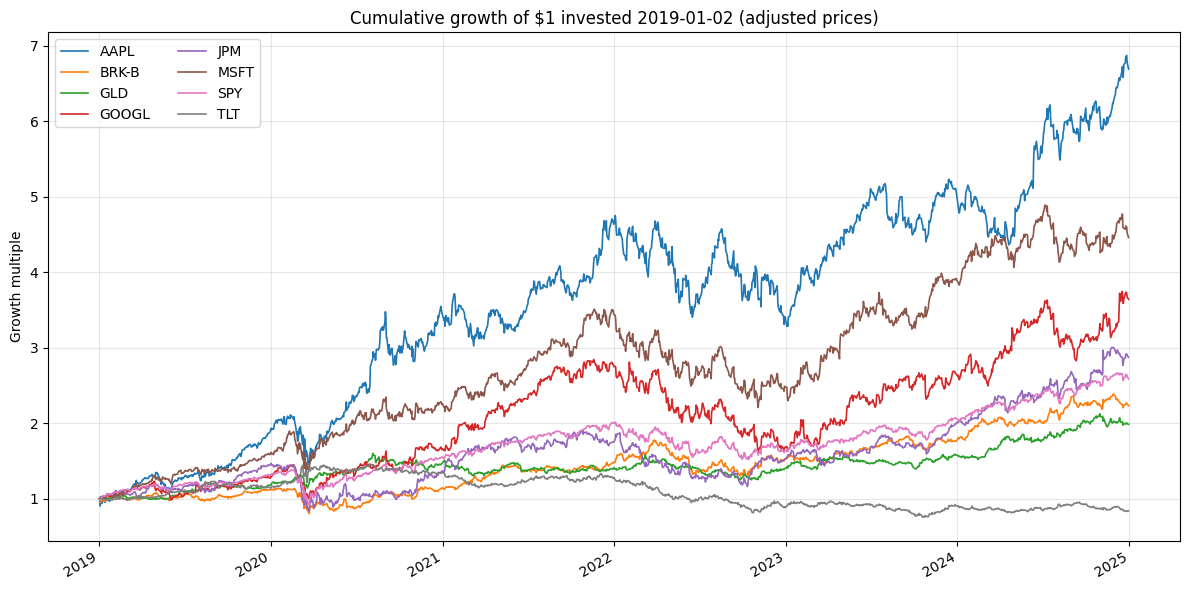

In [5]:
cum_growth = (prices / prices.iloc[0])

fig, ax = plt.subplots(figsize=(12, 6))
cum_growth.plot(ax=ax, linewidth=1.2)
ax.set_title("Cumulative growth of $1 invested 2019-01-02 (adjusted prices)")
ax.set_ylabel("Growth multiple")
ax.set_xlabel("")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

## Save

Persist to `../data/prices.csv` so downstream notebooks (`02_portfolio_metrics`, `03_var_analysis`, etc.) can read from a single canonical location.

In [6]:
prices.to_csv(PRICES_PATH)
print(f"Saved {len(prices)} rows × {len(prices.columns)} tickers → {PRICES_PATH}")

Saved 1509 rows × 8 tickers → ../data\prices.csv
